#Imports

In [1]:
import torch
from torch.utils.data import Dataset , DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, pad_sequence
import torch.nn.functional as F

#Loading the data and getting few insights of it

In [2]:
words = open('Indian_Names.txt' , 'r').read().splitlines()
print("First 10 words :-")
words[:10]

First 10 words :-


['Aaban',
 'Aabharan',
 'Aabhas',
 'Aabhat',
 'Aabheer',
 'Abheer',
 'Aabher',
 'Aabi',
 'Aabilesh',
 'Aabir']

In [3]:
print("Total number of words :-" , len(words))
print(f"Longest word :- {max(words , key = len)}")
print(f"Shortest word :- {min(words , key = len)}")

Total number of words :- 53982
Longest word :- Parthadhwajagrasamvasine
Shortest word :- An


#Building the vocabulary

In [4]:
chars = sorted(list(set(''.join(words))))
if '.' in chars:
    chars.remove('.')

str_to_idx = {s:i+2 for i,s in enumerate(chars)}
str_to_idx['.'] = 1
str_to_idx['<PAD>'] = 0

idx_to_str = {i:s for s,i in str_to_idx.items()}

#Building training , testing and dev sets

In [5]:
class CustomDataset(Dataset):
  def __init__(self , words , str_to_idx , block_size=3 , mode='mlp'):
    self.mode = mode # 2 modes mlp(for multiple layer posictrons) and seq(for RNN , LSTM and GRU)
    self.block_size = block_size
    self.str_to_idx = str_to_idx

    self.X = []
    self.Y = []

    for w in words:

      #for MLP
      if mode == 'mlp':
        context = [0] * block_size
        for ch in w + '.':
          idx = self.str_to_idx[ch]
          self.X.append(context)
          self.Y.append(idx)
          # The "Sliding Window" update:
          # context: [0, 0, 1] (current window)
          # 1. context[1:] -> [0, 1]       (CROP: removes the oldest character from the front)
          # 2. + [2]       -> [0, 1, 2]    (APPEND: adds the newest character to the back)
          # Result: window shifts forward by 1 but stays the same length.
          context = context[1:] + [idx]

      elif mode == 'seq':
        chars = ['.'] + list(w) + ['.']
        # .ram.
        # x = .ram
        # y = ram.
        x_seq = [self.str_to_idx[ch] for ch in chars[:-1]] #all except last
        y_seq = [self.str_to_idx[ch] for ch in chars[1:]] #all except first

        self.X.append(x_seq)
        self.Y.append(y_seq)

    if mode == "mlp":
            self.X = torch.tensor(self.X , dtype=torch.long)
            self.Y = torch.tensor(self.Y , dtype=torch.long)

  def __len__(self):
      return len(self.X)

  def __getitem__(self, idx):
      return self.X[idx], self.Y[idx]

In [6]:
import random

random.seed(42)
random.shuffle(words)

n = len(words)

n_train = int(0.8 * n)
n_dev   = int(0.9 * n)

train_words = words[:n_train]
dev_words   = words[n_train:n_dev]
test_words  = words[n_dev:]

In [7]:
train_dataset_mlp = CustomDataset(train_words, str_to_idx, block_size=10, mode='mlp')
dev_dataset_mlp   = CustomDataset(dev_words,   str_to_idx, block_size=10, mode='mlp')
test_dataset_mlp  = CustomDataset(test_words,  str_to_idx, block_size=10, mode='mlp')

In [8]:
train_dataset_seq = CustomDataset(train_words, str_to_idx, mode='seq')
dev_dataset_seq   = CustomDataset(dev_words,   str_to_idx, mode='seq')
test_dataset_seq  = CustomDataset(test_words,  str_to_idx, mode='seq')

In [9]:
def collate_seq(batch):
    # Unpack the batch of samples into separate lists for inputs (X) and targets (Y)
    # Each sample in 'batch' is expected to be a tuple (x_seq, y_seq)
    X, Y = zip(*batch)

    # Get original lengths of sequences before padding
    lengths = torch.tensor([len(x) for x in X], dtype=torch.long)

    # Convert each sequence in X and Y into a PyTorch tensor with long data type
    X = [torch.tensor(x, dtype=torch.long) for x in X]
    Y = [torch.tensor(y, dtype=torch.long) for y in Y]

    # Pad sequences in X to the same length, batch_first=True means the batch dimension comes first
    # padding_value=0 is used to fill shorter sequences to match the length of the longest sequence
    X_padded = pad_sequence(X, batch_first=True, padding_value=0)
    # Do the same for sequences in Y
    Y_padded = pad_sequence(Y, batch_first=True, padding_value=0)

    # Return the padded input, target tensors, and their original lengths
    return X_padded, Y_padded, lengths

In [10]:
train_loader_mlp = DataLoader(train_dataset_mlp, batch_size=32, shuffle=True)
dev_loader_mlp   = DataLoader(dev_dataset_mlp,   batch_size=32)
test_loader_mlp  = DataLoader(test_dataset_mlp,  batch_size=32)

In [11]:
train_loader_seq = DataLoader(train_dataset_seq, batch_size=32, shuffle=True, collate_fn=collate_seq)
dev_loader_seq   = DataLoader(dev_dataset_seq,   batch_size=32, collate_fn=collate_seq)
test_loader_seq  = DataLoader(test_dataset_seq,  batch_size=32, collate_fn=collate_seq)

#Models


##1.MLP

In [12]:
import torch
import torch.nn as nn

class MLP(torch.nn.Module):
  def __init__(self, vocab_size, embedding_dim, block_size, hidden_size):
    super().__init__()
    self.embedding = torch.nn.Embedding(vocab_size, embedding_dim)
    self.linear1 = torch.nn.Linear(block_size * embedding_dim, hidden_size)
    self.relu = torch.nn.ReLU()
    self.linear2 = torch.nn.Linear(hidden_size, vocab_size)

  def forward(self, x):
    # x is (batch_size, block_size)
    emb = self.embedding(x)  # (batch_size, block_size, embedding_dim)
    emb_flat = emb.reshape(emb.shape[0], -1)  # (batch_size, block_size * embedding_dim)
    h = self.relu(self.linear1(emb_flat))
    logits = self.linear2(h)  # (batch_size, vocab_size)
    return logits

#

##2.RNN

In [13]:
class RNN(torch.nn.Module):
  def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=1):
    super().__init__()
    self.embedding = torch.nn.Embedding(vocab_size, embedding_dim)
    self.rnn = torch.nn.RNN(embedding_dim, hidden_size, num_layers, batch_first=True)
    self.linear = torch.nn.Linear(hidden_size, vocab_size)

  def forward(self, x, lengths, hidden=None):
    # x is (batch_size, seq_len)
    # lengths is (batch_size,) → actual lengths of each sequence (without padding)

    emb = self.embedding(x)  # (batch_size, seq_len, embedding_dim)

    # Pack the padded sequence so RNN does not process padding tokens
    packed_emb = pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)

    # Pass through RNN
    packed_out, hidden_out = self.rnn(packed_emb, hidden)

    # Unpack back to padded sequence
    out, hidden = pad_packed_sequence(packed_out, batch_first=True)

    # Apply linear layer to each time step's output
    logits = self.linear(out)

    return logits, hidden_out

##3.LSTM

In [14]:
class LSTM(torch.nn.Module):
  def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=1):
    super().__init__()
    self.embedding = torch.nn.Embedding(vocab_size, embedding_dim)
    self.lstm = torch.nn.LSTM(embedding_dim, hidden_size, num_layers, batch_first=True)
    self.linear = torch.nn.Linear(hidden_size, vocab_size)

  def forward(self, x, lengths, hidden=None):
    # x is (batch_size, seq_len)
    # lengths is (batch_size,) → actual lengths of each sequence (without padding)

    emb = self.embedding(x)  # (batch_size, seq_len, embedding_dim)

    # Pack the padded sequence so LSTM does not process padding tokens
    packed_emb = pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)

    # Pass through LSTM
    packed_out, (hidden_out, cell_out) = self.lstm(packed_emb, hidden)

    # Unpack back to padded sequence
    out, _ = pad_packed_sequence(packed_out, batch_first=True, total_length=x.size(1))

    # Apply linear layer to each time step's output
    logits = self.linear(out)

    return logits, (hidden_out, cell_out)

##4.GRU

In [15]:
class GRU(torch.nn.Module):
  def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=1):
    super().__init__()
    self.embedding = torch.nn.Embedding(vocab_size, embedding_dim)
    self.gru = torch.nn.GRU(embedding_dim, hidden_size, num_layers, batch_first=True)
    self.linear = torch.nn.Linear(hidden_size, vocab_size)

  def forward(self, x, lengths, hidden=None):
    # x is (batch_size, seq_len)
    # lengths is (batch_size,) → actual lengths of each sequence (without padding)

    emb = self.embedding(x)  # (batch_size, seq_len, embedding_dim)

    # Pack the padded sequence so GRU does not process padding tokens
    packed_emb = pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)

    # Pass through GRU
    packed_out, hidden_out = self.gru(packed_emb, hidden)

    # Unpack back to padded sequence
    out, _ = pad_packed_sequence(packed_out, batch_first=True, total_length=x.size(1))

    # Apply linear layer to each time step's output
    logits = self.linear(out)

    return logits, hidden_out

#Training

In [16]:
def train_model(model, train_loader, optimizer, vocab_size, model_type, epochs, device="cpu"):
    model.train()

    loss_dict = {}

    for epoch in range(epochs):
        total_loss = 0

        for batch in train_loader:

            if model_type == "mlp":
                X, Y = batch
                X, Y = X.to(device), Y.to(device)

                logits = model(X)
                loss = F.cross_entropy(logits, Y)

            else:
                X, Y, lengths = batch
                X, Y, lengths = X.to(device), Y.to(device), lengths.to(device)

                logits, _ = model(X, lengths)

                loss = F.cross_entropy(
                    logits.view(-1, vocab_size),
                    Y.view(-1),
                    ignore_index=0
                )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        loss_dict[epoch] = avg_loss

        print(f"Epoch {epoch}: {avg_loss:.4f}")

    return loss_dict

In [17]:
#setting the device for training
device = "cuda" if torch.cuda.is_available() else "cpu"

In [18]:
#core hyper paras
EPOCHS = 10
BATCH_SIZE = 32

EMBEDDING_DIM = 64
HIDDEN_SIZE = 128
BLOCK_SIZE = 10

LEARNING_RATE = 0.001

In [19]:
vocab_size = len(str_to_idx)

In [20]:
#model definations
mlp_model = MLP(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    block_size=BLOCK_SIZE,
    hidden_size=HIDDEN_SIZE
).to(device)


rnn_model = RNN(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE
).to(device)


lstm_model = LSTM(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE
).to(device)


gru_model = GRU(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE
).to(device)

In [21]:
#optimizer for each model
optimizer_mlp  = torch.optim.Adam(mlp_model.parameters(), lr=LEARNING_RATE)
optimizer_rnn  = torch.optim.Adam(rnn_model.parameters(), lr=LEARNING_RATE)
optimizer_lstm = torch.optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE)
optimizer_gru  = torch.optim.Adam(gru_model.parameters(), lr=LEARNING_RATE)

In [22]:
#MLP training
mlp_losses = train_model(
    mlp_model,
    train_loader_mlp,
    optimizer_mlp,
    vocab_size,
    model_type="mlp",
    epochs=EPOCHS,
    device=device
)

Epoch 0: 1.9466
Epoch 1: 1.8501
Epoch 2: 1.8200
Epoch 3: 1.8010
Epoch 4: 1.7868
Epoch 5: 1.7769
Epoch 6: 1.7682
Epoch 7: 1.7620
Epoch 8: 1.7554
Epoch 9: 1.7504


In [23]:
#RNN training
rnn_losses = train_model(
    rnn_model,
    train_loader_seq,
    optimizer_rnn,
    vocab_size,
    model_type="seq",
    epochs=EPOCHS,
    device=device
)

Epoch 0: 2.0175
Epoch 1: 1.8877
Epoch 2: 1.8510
Epoch 3: 1.8293
Epoch 4: 1.8133
Epoch 5: 1.8020
Epoch 6: 1.7924
Epoch 7: 1.7838
Epoch 8: 1.7769
Epoch 9: 1.7712


In [24]:
#LSTM training
lstm_losses = train_model(
    lstm_model,
    train_loader_seq,
    optimizer_lstm,
    vocab_size,
    model_type="seq",
    epochs=EPOCHS,
    device=device
)

Epoch 0: 2.0330
Epoch 1: 1.8652
Epoch 2: 1.8193
Epoch 3: 1.7897
Epoch 4: 1.7683
Epoch 5: 1.7509
Epoch 6: 1.7365
Epoch 7: 1.7241
Epoch 8: 1.7136
Epoch 9: 1.7042


In [25]:
#GRU training
gru_losses = train_model(
    gru_model,
    train_loader_seq,
    optimizer_gru,
    vocab_size,
    model_type="seq",
    epochs=EPOCHS,
    device=device
)

Epoch 0: 2.0061
Epoch 1: 1.8490
Epoch 2: 1.8056
Epoch 3: 1.7778
Epoch 4: 1.7586
Epoch 5: 1.7432
Epoch 6: 1.7313
Epoch 7: 1.7211
Epoch 8: 1.7120
Epoch 9: 1.7040


In [26]:
#Storing the results in a dictionary
results = {
    "MLP": mlp_losses,
    "RNN": rnn_losses,
    "LSTM": lstm_losses,
    "GRU": gru_losses
}

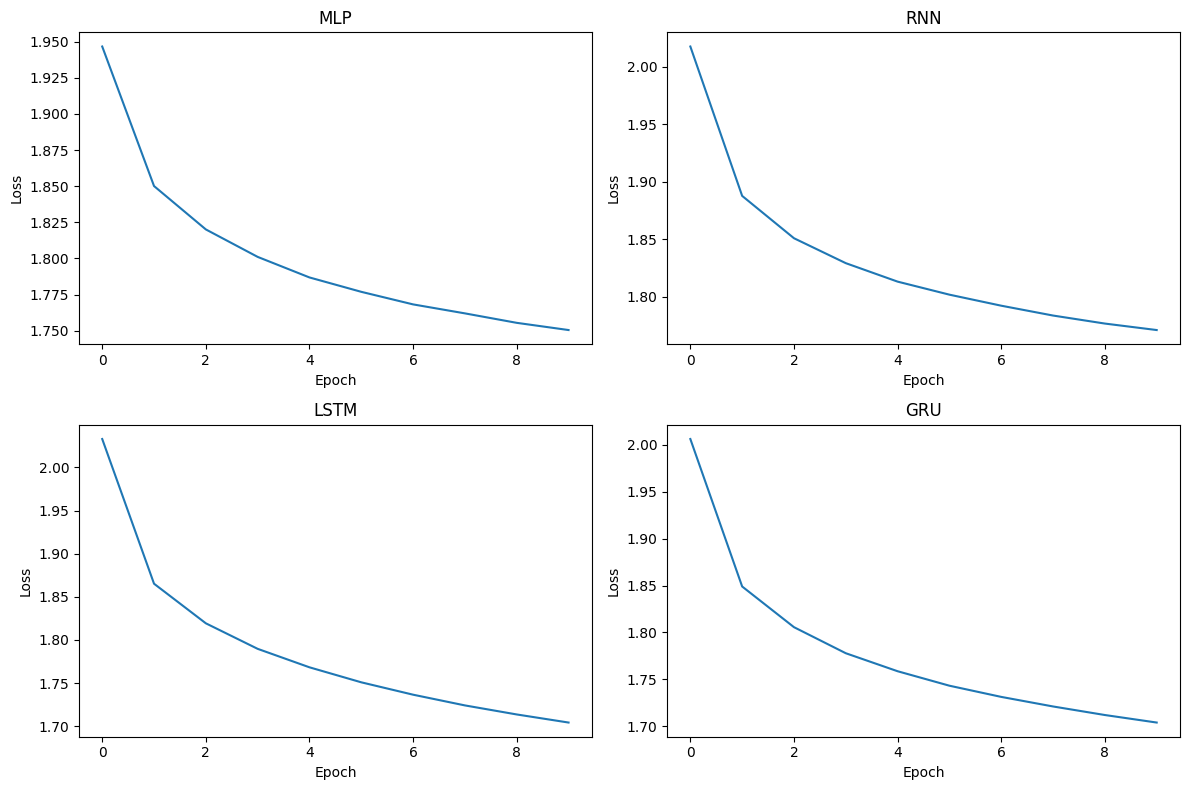

In [27]:
#Loss vs Epoch plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes = axes.flatten()

for i, (name, loss_dict) in enumerate(results.items()):
    axes[i].plot(list(loss_dict.keys()), list(loss_dict.values()))
    axes[i].set_title(name)
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Loss")

plt.tight_layout()
plt.savefig("loss_vs_epoch_train_plot.png")
plt.show()

#Evaluation

In [28]:
def evaluate_model(model, data_loader, vocab_size, model_type, device="cpu"):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in data_loader:

            if model_type == "mlp":
                X, Y = batch
                X, Y = X.to(device), Y.to(device)

                logits = model(X)
                loss = F.cross_entropy(logits, Y)

            else:
                X, Y, lengths = batch
                X, Y, lengths = X.to(device), Y.to(device), lengths.to(device)

                logits, _ = model(X, lengths)

                loss = F.cross_entropy(
                    logits.view(-1, vocab_size),
                    Y.view(-1),
                    ignore_index=0
                )

            total_loss += loss.item()

    avg_loss = total_loss / len(data_loader)
    perplexity = torch.exp(torch.tensor(avg_loss)).item()

    return {
        "loss": avg_loss,
        "perplexity": perplexity
    }

##Evaluation on Dev set

In [29]:
dev_results = {
    "MLP": evaluate_model(mlp_model, dev_loader_mlp, vocab_size, "mlp", device),
    "RNN": evaluate_model(rnn_model, dev_loader_seq, vocab_size, "seq", device),
    "LSTM": evaluate_model(lstm_model, dev_loader_seq, vocab_size, "seq", device),
    "GRU": evaluate_model(gru_model, dev_loader_seq, vocab_size, "seq", device),
}

In [30]:
test_results = {
    "MLP": evaluate_model(mlp_model, test_loader_mlp, vocab_size, "mlp", device),
    "RNN": evaluate_model(rnn_model, test_loader_seq, vocab_size, "seq", device),
    "LSTM": evaluate_model(lstm_model, test_loader_seq, vocab_size, "seq", device),
    "GRU": evaluate_model(gru_model, test_loader_seq, vocab_size, "seq", device),
}

In [31]:
for name in ["MLP", "RNN", "LSTM", "GRU"]:

    train_loss = list(results[name].values())[-1]
    train_ppl  = torch.exp(torch.tensor(train_loss)).item()

    dev_loss = dev_results[name]["loss"]
    dev_ppl  = dev_results[name]["perplexity"]

    test_loss = test_results[name]["loss"]
    test_ppl  = test_results[name]["perplexity"]

    print(f"\n{name}")
    print(f"Train → Loss: {train_loss:.4f}, Perplexity: {train_ppl:.4f}")
    print(f"Dev   → Loss: {dev_loss:.4f}, Perplexity: {dev_ppl:.4f}")
    print(f"Test  → Loss: {test_loss:.4f}, Perplexity: {test_ppl:.4f}")


MLP
Train → Loss: 1.7504, Perplexity: 5.7571
Dev   → Loss: 1.8506, Perplexity: 6.3634
Test  → Loss: 1.8411, Perplexity: 6.3032

RNN
Train → Loss: 1.7712, Perplexity: 5.8781
Dev   → Loss: 1.8047, Perplexity: 6.0784
Test  → Loss: 1.7988, Perplexity: 6.0424

LSTM
Train → Loss: 1.7042, Perplexity: 5.4972
Dev   → Loss: 1.7559, Perplexity: 5.7887
Test  → Loss: 1.7464, Perplexity: 5.7339

GRU
Train → Loss: 1.7040, Perplexity: 5.4957
Dev   → Loss: 1.7581, Perplexity: 5.8012
Test  → Loss: 1.7496, Perplexity: 5.7524


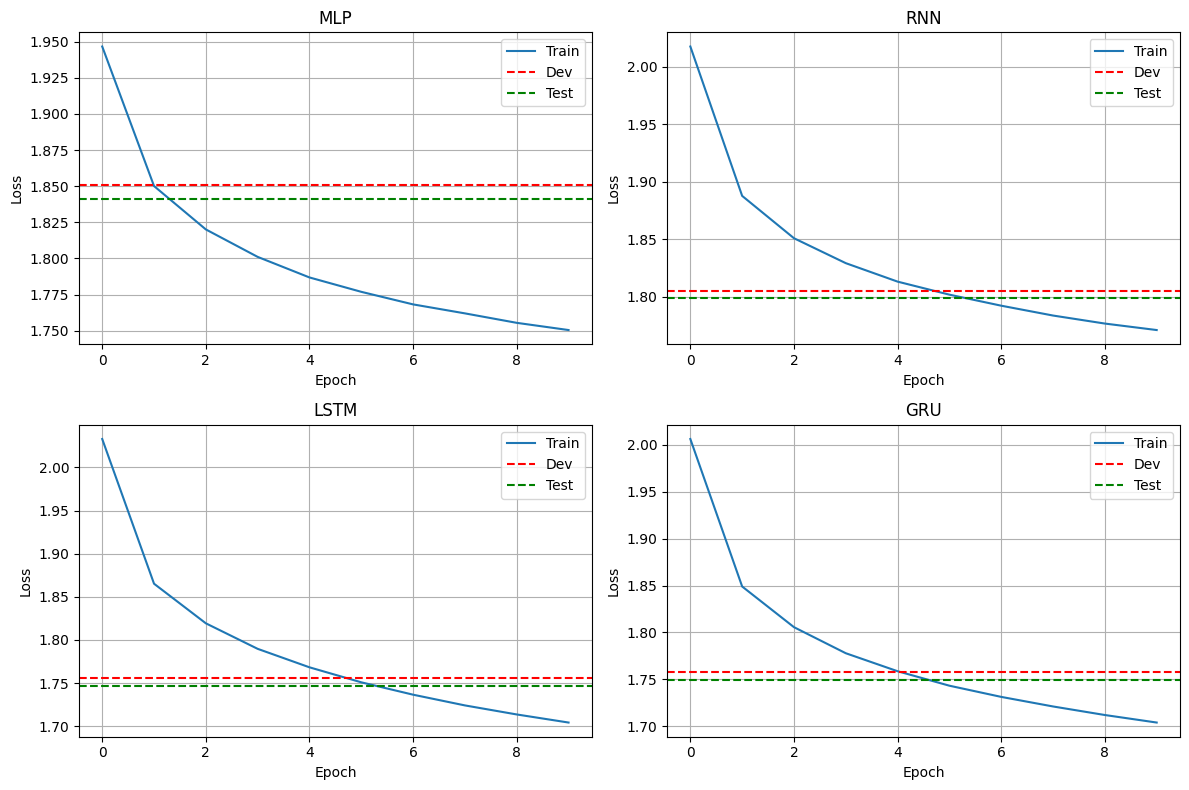

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, name in enumerate(["MLP", "RNN", "LSTM", "GRU"]):

    train_epochs = list(results[name].keys())
    train_losses = list(results[name].values())

    dev_loss = dev_results[name]["loss"]
    test_loss = test_results[name]["loss"]

    axes[i].plot(train_epochs, train_losses, label="Train")
    axes[i].axhline(y=dev_loss, color='r', linestyle='--', label="Dev")
    axes[i].axhline(y=test_loss, color='g', linestyle='--', label="Test")

    axes[i].set_title(name)
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Loss")
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.savefig("loss_vs_epoch_train_Eval_plot.png")
plt.show()

#Demo

In [33]:
def sample_all_models(models, stoi, itos, block_size=3, num_samples=10, start_char='.', device=None):
    results = {}

    start_idx = stoi[start_char]
    end_idx = stoi['.']

    min_len = 3
    temperature = 0.8
    max_len = 30

    for name, model in models.items():
        model.eval()

        model_device = next(model.parameters()).device
        names = []

        for _ in range(num_samples):

            # -------- MLP --------
            if name == "MLP":
                context = [0] * block_size
                context[-1] = start_idx

                out = [start_idx]

                for _ in range(max_len):
                    x = torch.tensor([context], dtype=torch.long, device=model_device)

                    logits = model(x)
                    probs = F.softmax(logits / temperature, dim=1)

                    ix = torch.multinomial(probs, num_samples=1).item()

                    if ix == end_idx and len(out) > min_len:
                        break

                    if ix != end_idx:
                        out.append(ix)

                    context = context[1:] + [ix]

            # -------- SEQ MODELS --------
            else:
                out = [start_idx]
                ix = start_idx
                hidden = None

                for _ in range(max_len):
                    x = torch.tensor([[ix]], dtype=torch.long, device=model_device)
                    lengths = torch.tensor([1], device=model_device)

                    logits, hidden = model(x, lengths, hidden)
                    probs = F.softmax(logits[:, -1, :] / temperature, dim=1)

                    ix = torch.multinomial(probs, num_samples=1).item()

                    if ix == end_idx and len(out) > min_len:
                        break

                    if ix != end_idx:
                        out.append(ix)

            name_str = ''.join([itos[i] for i in out if i != 0])
            names.append(name_str)

        results[name] = names

    return results

In [34]:
models = {
    "MLP": mlp_model,
    "RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model
}

outputs = sample_all_models(models, str_to_idx, idx_to_str, block_size=BLOCK_SIZE, start_char='a')

In [35]:
for model_name, names in outputs.items():
    print(f"\n{model_name}:")
    for n in names:
        print(n)


MLP:
anjeena
ayalaksimi
anni
agel
aagizhthi
alata
adeesan
abalashree
akanan
adeeseghitha

RNN:
anandra
atchithra
amkaran
anan
amaroshini
anthamani
amannoush
anthushali
anthika
anath

LSTM:
ankBardhini
aAryavan
allishi
aesVanuja
agas
arungaram
avan
arshai
akshiga
amiRaka

GRU:
avarshini
ahini
aarumani
aAshvi
asenth
andi
aliara
akshana
ahianan
anka


#Saving the models

In [36]:
for model_name, model in models.items():
    torch.save(model, f"{model_name.lower()}_model.pkl")
    print(f"Saved {model_name} model to {model_name.lower()}_model.pkl")

Saved MLP model to mlp_model.pkl
Saved RNN model to rnn_model.pkl
Saved LSTM model to lstm_model.pkl
Saved GRU model to gru_model.pkl
